# Simple Linear Regression

## What is simple linear regression?

Linear regression predicts a continuous target by fitting a straight-line relationship between inputs and outputs. **Simple** linear regression uses exactly one input feature:

$$\hat{y} = b_0 + b_1x$$

where:

- $x$ is the input feature, such as engine size
- $\hat{y}$ is the predicted target, such as CO₂ emissions
- $b_0$ is the intercept, which positions the line vertically
- $b_1$ is the slope, or coefficient

The slope answers a concrete question: **how much does the model's prediction change when the input increases by one unit?**

Training chooses $b_0$ and $b_1$ to minimize the **sum of squared residuals** on the training data:

$$sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

A residual is the difference between an observed value and its prediction. Squaring residuals prevents positive and negative errors from cancelling and penalizes large errors more strongly.

> A fitted relationship is *predictive*, not automatically causal. A line can describe an association without proving that changing the feature would directly cause the target to change.

## Objectives

After completing this lab, you should be able to:

- Explain the slope, intercept, prediction, and residual
- Train and test a simple linear regression model with scikit-learn
- Keep training and test data conceptually separate
- Evaluate predictions with MAE, MSE, RMSE, R-squared, and residual plots
- Compare two candidate features on the same held-out observations
- Recognize extrapolation and other limitations of a straight-line model


## Install needed packages

This lab requires NumPy, Matplotlib, pandas, and scikit-learn. If they are unavailable, install them from a terminal with:

```bash
uv pip install -r requirements.txt
```

## Import the libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Load dataset

The dataset we will use is stored in the `fuel_consumption_co2.csv` file.

We'll use the file path with the Pandas library to load the dataset.

In [2]:
df = pd.read_csv('fuel_consumption_co2.csv')

In [3]:
# Verify successful dataset load with some randomly selected records
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
126,2014,BMW,X1 xDRIVE28i,SUV - SMALL,2.0,4,A8,Z,10.6,7.2,9.1,31,209
57,2014,AUDI,S5,SUBCOMPACT,3.0,6,A7,Z,13.2,9.2,11.4,25,262
711,2014,MAZDA,MAZDA3 5-DOOR (i-ELOOP),MID-SIZE,2.5,4,AS6,X,8.2,6.1,7.3,39,168
461,2014,GMC,SIERRA 4WD,PICKUP TRUCK - STANDARD,5.3,8,A6,E,19.9,14.2,17.3,16,277
273,2014,CHEVROLET,TRAX AWD,SUV - SMALL,1.4,4,AS6,X,10.0,7.8,9.0,31,207



## Understand the data

We are using a fuel consumption dataset, `fuel_consumption_co2.csv`, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada.

- **MODEL YEAR** e.g. 2014
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182

Our task is to choose one feature and use it to predict CO₂ emissions for vehicles the model did not see during training. The rows contain standardized vehicle ratings, not measurements of how individual drivers actually operate their cars.

### Explore the data

First, let's consider a statistical summary of the data.

In [4]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


The summary describes numerical columns only.

- `MODELYEAR` has a standard deviation of zero because every row is from 2014. A constant feature cannot explain differences among vehicles.
- MPG ranges from 11 to 60. A value near the edge of a distribution is not automatically an error. Before calling it an outlier, inspect the corresponding vehicle and fuel type.
- `describe()` does not show categorical variables such as fuel type or vehicle class, but those variables may still explain important structure.

Summary statistics are a starting point. They do not tell us by themselves whether relationships are linear or whether unusual values are invalid.


#### Select candidate features

We will inspect engine size, cylinders, and combined fuel consumption as possible one-feature predictors. This is exploratory analysis: looking at several candidates before choosing the feature used in the first model.


In [5]:
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
21,2.0,4,9.3,214
893,4.8,8,13.9,320
565,5.0,8,13.7,315
25,2.0,4,10.2,235
386,3.7,6,18.0,288
445,5.3,8,16.5,380
435,5.3,8,15.9,366
771,5.5,8,12.7,292
822,2.0,4,8.6,198


#### Visualize features

Consider the histograms for each of these features.

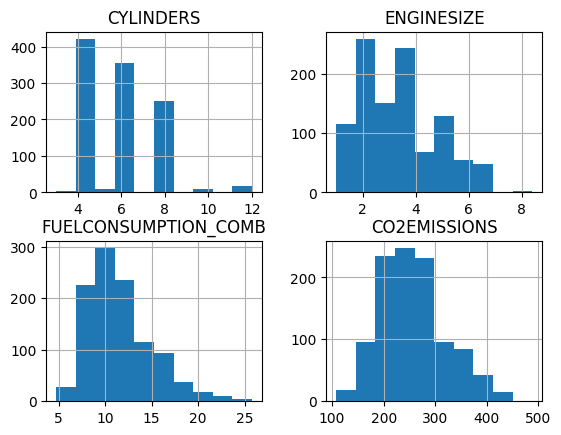

In [6]:
viz = cdf[['CYLINDERS', 'ENGINESIZE', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
viz.hist()
plt.show()

Most vehicles have 4, 6, or 8 cylinders, with engine sizes concentrated around 2 to 4 liters. Histograms show each variable separately, but they do not show whether one variable predicts another. Scatter plots are more useful for examining the shape, direction, and spread of a feature-target relationship.


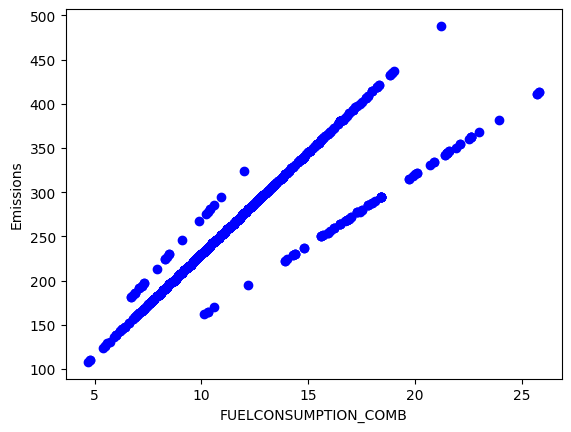

In [7]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('Emissions')
plt.show()

Combined fuel consumption has a strong positive relationship with CO2 emissions: vehicles rated to consume more liters per 100 km generally have higher rated emissions.

The points form several narrow bands. Fuel type is a plausible explanation because fuels differ in carbon content, but the plot alone does not prove the cause. The dataset contains more than three fuel codes, and we should verify group membership directly before assigning every band to a particular fuel.

This feature looks promising, although one straight line may still average across group-specific relationships.


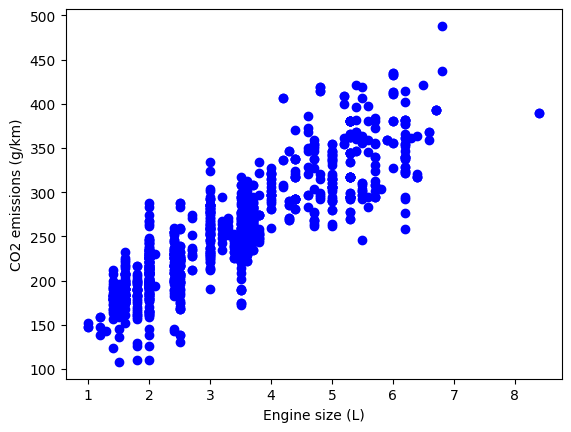

In [8]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('Engine size (L)')
plt.ylabel('CO2 emissions (g/km)')
plt.show()


Engine size and rated CO2 emissions have a broadly positive, approximately linear relationship, but the points have more vertical spread than in the fuel-consumption plot.

That spread means vehicles with similar engine sizes can have quite different emissions. Other vehicle characteristics, such as fuel type, efficiency, weight, transmission, and vehicle class, may explain part of the difference. The dataset contains standardized ratings, so this comparison should not be explained in terms of one driver being gentle and another driving aggressively.

Engine size is still a reasonable feature for demonstrating simple linear regression.

---

### Practice exercise

Plot __CYLINDER__ against CO₂ Emissions, to see how linear their relationship is.

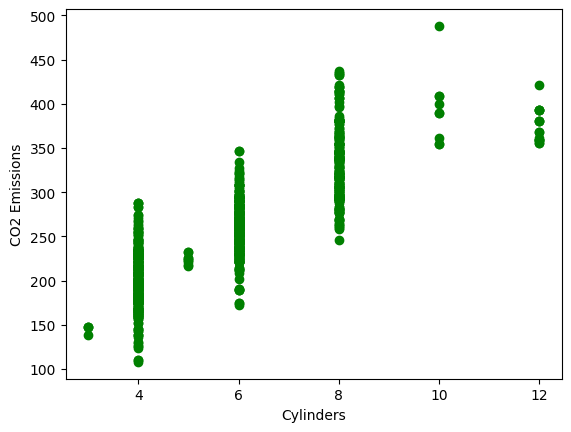

In [9]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='green')
plt.xlabel('Cylinders')
plt.ylabel('CO2 Emissions')
plt.show()

Cylinder count takes only a few discrete values, so observations form vertical columns. It can still be used in regression, but a straight line assumes that moving from 4 to 6 cylinders has the same average effect per cylinder as moving from 6 to 8. Engine size gives a more continuous input for this introductory example.


### Extract the input feature and target

We will first use engine size to predict CO₂ emissions. Keeping `X` two-dimensional from the beginning gives it the shape scikit-learn expects: `(number of observations, number of features)`. Because this is simple regression, the second dimension has size 1.

In [10]:
X_engine = cdf[['ENGINESIZE']].to_numpy()
y = cdf['CO2EMISSIONS'].to_numpy()

print('Feature shape:', X_engine.shape)
print('Target shape:', y.shape)


Feature shape: (1067, 1)


Target shape: (1067,)


#### Create training and test datasets

The model learns its slope and intercept from the training set. The test set is held back to estimate performance on unseen vehicles.

We use the same test rows when comparing candidate features later. Otherwise, a model might appear better simply because it received an easier test sample.

An 80/20 split is a common teaching choice, not a universal rule. With limited data, cross-validation usually gives a more stable performance estimate than relying on one random split.


In [11]:
from sklearn.model_selection import train_test_split

# Split row indices once so every candidate model uses identical train/test rows.
train_index, test_index = train_test_split(
    np.arange(len(cdf)),
    test_size=0.2,
    random_state=42,
)

X_engine_train = X_engine[train_index]
X_engine_test = X_engine[test_index]
y_train = y[train_index]
y_test = y[test_index]


The feature arrays are two-dimensional because scikit-learn expects rows by features. The target remains one-dimensional because there is one observed outcome per row.


In [12]:
print('X training shape:', X_engine_train.shape)
print('X test shape:', X_engine_test.shape)
print('y training shape:', y_train.shape)
print('y test shape:', y_test.shape)


X training shape: (853, 1)


X test shape: (214, 1)


y training shape: (853,)


y test shape: (214,)


### Build a simple linear regression model

Scikit-learn's `LinearRegression` learns the line that minimizes squared residuals on the training set.

Unlike many algorithms, ordinary unregularized linear regression does **not** require feature standardization for prediction. Scaling one input feature changes the numerical slope and intercept but not the fitted predictions after converting back to the original units. We therefore keep engine size in liters so the coefficient remains easy to interpret.


In [13]:
from sklearn.linear_model import LinearRegression

engine_model = LinearRegression()
engine_model.fit(X_engine_train, y_train)

print(f'Coefficient: {engine_model.coef_[0]:.2f} g/km per liter')
print(f'Intercept: {engine_model.intercept_:.2f} g/km')


Coefficient: 38.99 g/km per liter


Intercept: 126.29 g/km


The fitted equation is:

$$\widehat{CO2} = b_0 + b_1(\text{engine size})$$

- The **slope** $b_1$ is the predicted change in CO₂ emissions for a one-liter increase in engine size.
- The **intercept** $b_0$ is where the mathematical line crosses the y-axis.

The intercept should not be interpreted literally as the emissions of a real zero-liter vehicle. Zero liters lies outside the observed engine-size range, so that interpretation would be an extrapolation. Within the data range, the intercept and slope work together to position the best-fit line.

The slope describes an association in this dataset; it does not prove that changing engine size alone would cause exactly that emissions change.


### Visualize the fitted line

The blue points are training observations and the red line contains the model's predictions. The vertical distance from each point to the line is its residual.

Sort the x-values before drawing the line so that Matplotlib connects predictions from left to right.


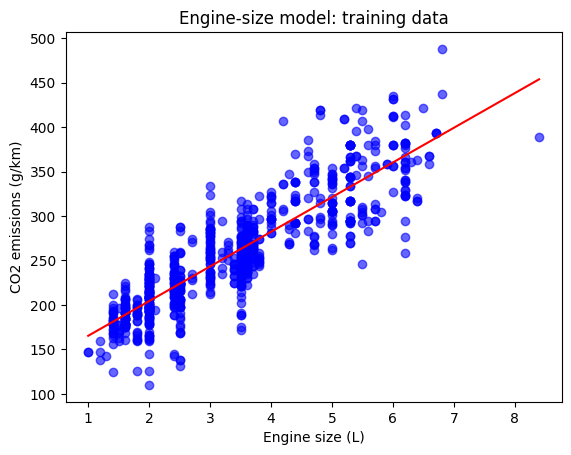

In [14]:
engine_order = np.argsort(X_engine_train[:, 0])

plt.scatter(X_engine_train[:, 0], y_train, color='blue', alpha=0.6)
plt.plot(
    X_engine_train[engine_order, 0],
    engine_model.predict(X_engine_train[engine_order]),
    color='red',
)
plt.xlabel('Engine size (L)')
plt.ylabel('CO2 emissions (g/km)')
plt.title('Engine-size model: training data')
plt.show()


#### Evaluate on unseen test data

Training fit tells us how well the model matches data it already used. Test metrics estimate how it generalizes to held-out vehicles.

- **MAE:** average absolute error, in g/km.
- **MSE:** average squared error, in squared units. It is related to the training objective but is not the same quantity as the residual sum of squares.
- **RMSE:** square root of MSE, returned to g/km and more sensitive to large errors than MAE.
- **R-squared:** improvement relative to always predicting the test target mean. A score of 1 is perfect, 0 matches that baseline, and negative values are worse.

Regression metrics describe error, not "accuracy" in the classification sense.


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

engine_pred = engine_model.predict(X_engine_test)

engine_results = {
    'MAE': mean_absolute_error(y_test, engine_pred),
    'MSE': mean_squared_error(y_test, engine_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, engine_pred)),
    'R2': r2_score(y_test, engine_pred),
}

for metric, value in engine_results.items():
    print(f'{metric}: {value:.2f}')


MAE: 24.10


MSE: 985.94


RMSE: 31.40


R2: 0.76


**How to interpret the engine-size results:**

- MAE estimates the typical error in g/km.
- RMSE being larger than MAE indicates that some relatively large errors are receiving extra weight.
- R-squared reports how much better the model is than the mean-prediction baseline on this particular test split.

Do not label a score universally "good" or "bad" without considering the application and an acceptable error range. Also remember that one random split produces one estimate; cross-validation gives a more stable comparison.


## Practice and comparison

Now repeat the workflow with combined fuel consumption. The comparison is fair because both models use the same training rows, test rows, and target values.


#### 1. Plot the regression model result over the test data instead of the training data. Visually evaluate whether the result is good.


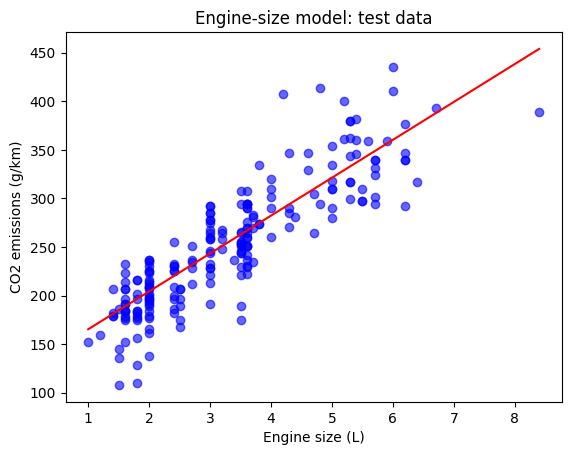

In [16]:
engine_test_order = np.argsort(X_engine_test[:, 0])

plt.scatter(X_engine_test[:, 0], y_test, color='blue', alpha=0.6)
plt.plot(
    X_engine_test[engine_test_order, 0],
    engine_model.predict(X_engine_test[engine_test_order]),
    color='red',
)
plt.xlabel('Engine size (L)')
plt.ylabel('CO2 emissions (g/km)')
plt.title('Engine-size model: test data')
plt.show()


Let's see the evaluation metrics if we train a regression model using the `FUELCONSUMPTION_COMB` feature.

#### 2. Select the fuel consumption feature from the dataframe and split the data 80%/20% into training and testing sets

Use the same random state as previously so you can make an objective comparison to the previous training result.

In [17]:
X_fuel = cdf[['FUELCONSUMPTION_COMB']].to_numpy()

X_fuel_train = X_fuel[train_index]
X_fuel_test = X_fuel[test_index]


#### 3.  Train a linear regression model using the training data we just created

Remember we need to transform the 1D feature into a 2D array.

In [18]:
fuel_model = LinearRegression()
fuel_model.fit(X_fuel_train, y_train)

print(f'Coefficient: {fuel_model.coef_[0]:.2f} g/km per L/100 km')
print(f'Intercept: {fuel_model.intercept_:.2f} g/km')


Coefficient: 16.18 g/km per L/100 km


Intercept: 69.10 g/km


#### 4. Use the model to make test predictions on the fuel consumption testing data

In [19]:
fuel_pred = fuel_model.predict(X_fuel_test)


#### 5. Calculate and print all four evaluation metrics for the fuel consumption model: MAE, MSE, RMSE, and R²

In [20]:
fuel_results = {
    'MAE': mean_absolute_error(y_test, fuel_pred),
    'MSE': mean_squared_error(y_test, fuel_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, fuel_pred)),
    'R2': r2_score(y_test, fuel_pred),
}

for metric, value in fuel_results.items():
    print(f'{metric}: {value:.2f}')


MAE: 20.44


MSE: 797.43


RMSE: 28.24


R2: 0.81


Compare these values with `engine_results`. Lower error metrics and a higher test R-squared indicate better predictive performance on these held-out rows. The difference applies to this dataset and split; it is evidence, not a universal law that fuel consumption must outperform every other feature in every dataset.


#### 6. Plot the fuel consumption regression line over the test data (like Exercise 1 did for engine size). Does the fit look better visually?

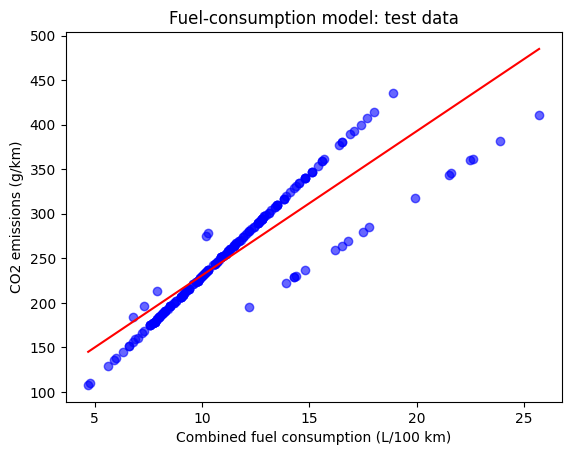

In [21]:
fuel_test_order = np.argsort(X_fuel_test[:, 0])

plt.scatter(X_fuel_test[:, 0], y_test, color='blue', alpha=0.6)
plt.plot(
    X_fuel_test[fuel_test_order, 0],
    fuel_model.predict(X_fuel_test[fuel_test_order]),
    color='red',
)
plt.xlabel('Combined fuel consumption (L/100 km)')
plt.ylabel('CO2 emissions (g/km)')
plt.title('Fuel-consumption model: test data')
plt.show()


#### 7. Compare both models side by side and explain why one outperforms the other

Run the cell below to print a comparison table, then read the explanation that follows.

In [22]:
comparison = pd.DataFrame({
    'Engine size': engine_results,
    'Fuel consumption': fuel_results,
})

comparison


,Engine size,Fuel consumption
MAE,24.097257,20.441911
MSE,985.938169,797.434631
RMSE,31.399652,28.238885
R2,0.761560,0.807147


### Why might fuel consumption predict better here?

Rated CO₂ emissions are closely related to the amount and type of fuel consumed, so combined fuel consumption is conceptually closer to the target than engine size. Engine size is an indirect proxy: vehicles with the same engine size can differ in efficiency, fuel, weight, transmission, and other design characteristics.

Still, avoid overclaiming causality from this notebook alone:

- The scatter plot contains fuel-related groups, so one line averages across potentially different relationships.
- The target and fuel-consumption rating may be derived from closely related testing procedures, which can make prediction easier without constituting an independent causal experiment.
- Better performance on one held-out split does not guarantee the same ranking on new datasets.

The defensible conclusion is narrower: **on the same test rows in this dataset, the fuel-consumption model has lower prediction error and higher R-squared than the engine-size model.**


### Inspect residuals

A residual plot can reveal structure hidden by summary metrics. Ideally, residuals are scattered around zero without a curve, funnel shape, or separated groups. Visible patterns suggest that one straight line is missing useful structure.


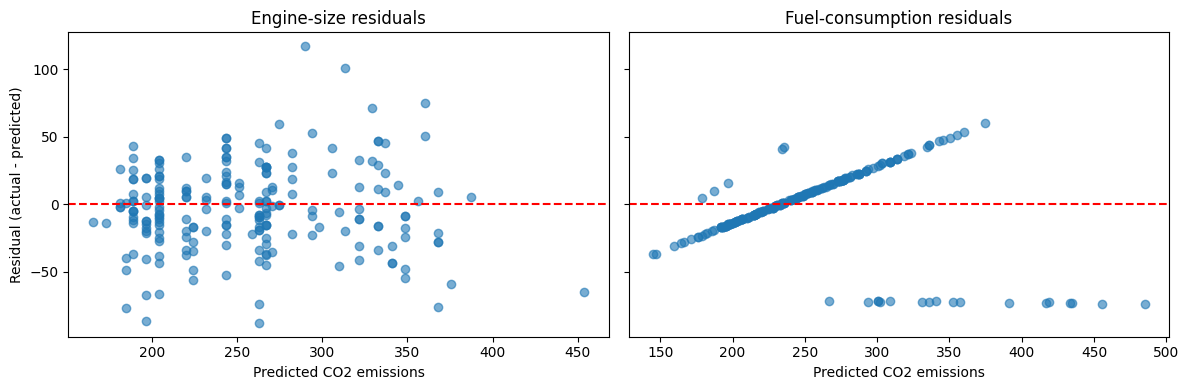

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].scatter(engine_pred, y_test - engine_pred, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Engine-size residuals')
axes[0].set_xlabel('Predicted CO2 emissions')
axes[0].set_ylabel('Residual (actual - predicted)')

axes[1].scatter(fuel_pred, y_test - fuel_pred, alpha=0.6)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Fuel-consumption residuals')
axes[1].set_xlabel('Predicted CO2 emissions')

plt.tight_layout()
plt.show()


## Takeaways

1. Simple linear regression fits one straight-line relationship between one feature and a continuous target.
2. The slope is a change in the prediction per unit of the feature; it is not automatically a causal effect.
3. The intercept may have little physical meaning when zero is outside the observed feature range.
4. Keep test observations out of training and compare candidate features on the same held-out rows.
5. Ordinary simple linear regression does not need standardization for prediction, and original units make the slope easier to interpret.
6. MAE, RMSE, and R-squared answer different evaluation questions; MSE is not the same as residual sum of squares.
7. Metrics summarize predictive performance, while residual plots reveal missed patterns.
8. A better feature in one dataset is not guaranteed to be better everywhere. Validate conclusions with repeated splits or cross-validation.

Natural next steps are multiple regression, categorical encoding for fuel type, and models or transformations that can represent group-specific or nonlinear structure.
